 # Week 7
 # AAPL Historical Stock Market Dataset From Yahoo Fiance

In [1]:
import numpy as np 
import pandas as pd 
import yfinance as yf 
aapl_data =yf.download("AAPL",start="2023-01-01",end="2026-01-01")
print(aapl_data)


[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2023-01-03  122.876740  128.604497  121.992521  127.995375  112117500
2023-01-04  124.144119  126.403789  122.886567  124.664824   89113600
2023-01-05  122.827629  125.529405  122.572194  124.900628   80962700
2023-01-06  127.346909  128.005157  122.699861  123.800222   87754700
2023-01-09  127.867630  131.070471  127.612195  128.182026   70790800
...                ...         ...         ...         ...        ...
2025-12-24  273.066742  274.682340  271.461127  271.600731   17910600
2025-12-26  272.657806  274.622460  272.119264  273.415753   21521800
2025-12-29  273.016876  273.615223  271.610700  271.949773   23715200
2025-12-30  272.338684  273.335969  271.540868  272.069428   22139600
2025-12-31  271.122009  272.937076  271.012322  272.318764   27293600

[752 rows x 5 colum

In [2]:
aapl_data.info

<bound method DataFrame.info of Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2023-01-03  122.876740  128.604497  121.992521  127.995375  112117500
2023-01-04  124.144119  126.403789  122.886567  124.664824   89113600
2023-01-05  122.827629  125.529405  122.572194  124.900628   80962700
2023-01-06  127.346909  128.005157  122.699861  123.800222   87754700
2023-01-09  127.867630  131.070471  127.612195  128.182026   70790800
...                ...         ...         ...         ...        ...
2025-12-24  273.066742  274.682340  271.461127  271.600731   17910600
2025-12-26  272.657806  274.622460  272.119264  273.415753   21521800
2025-12-29  273.016876  273.615223  271.610700  271.949773   23715200
2025-12-30  272.338684  273.335969  271.540868  272.069428   22139600
2025-12-31  271.122009  272.937076  271.012322  272.318764

In [3]:
aapl_data.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [4]:
aapl_data.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,752.000000,752.000000,752.000000,752.000000,7.520000e+02
mean,202.167914,203.987273,200.129001,201.923572,5.683609e+07
std,34.308362,34.599409,33.995258,34.341919,2.461348e+07
min,122.827629,125.529405,121.992521,123.800222,1.791060e+07
25%,175.535629,177.195905,173.958608,175.128581,4.368122e+07
50%,197.306412,199.348851,194.449116,196.754807,5.116750e+07
75%,226.413052,228.501767,224.321886,226.678786,6.344492e+07
max,285.413116,287.836529,282.530963,285.423116,3.186799e+08


### Filtering And Data Sorting 

### Filtering

In [5]:
high_price_data=aapl_data[aapl_data["Close"]>200]
print(high_price_data.head())

Price      Close High  Low Open Volume
Ticker      AAPL AAPL AAPL AAPL   AAPL
Date                                  
2023-01-03   NaN  NaN  NaN  NaN    NaN
2023-01-04   NaN  NaN  NaN  NaN    NaN
2023-01-05   NaN  NaN  NaN  NaN    NaN
2023-01-06   NaN  NaN  NaN  NaN    NaN
2023-01-09   NaN  NaN  NaN  NaN    NaN


### Sorting

In [6]:
aapl_data.columns=aapl_data.columns.get_level_values(0)


In [7]:
sorted_data=aapl_data.sort_values(by="Close",ascending=False)
print(sorted_data.head())

Price            Close        High         Low        Open    Volume
Date                                                                
2025-12-02  285.413116  286.619823  281.862783  282.231774  53669500
2025-12-03  283.378662  287.836529  282.530963  285.423116  43538700
2025-12-01  282.331482  282.650621  275.390385  277.255303  46587700
2025-12-04  279.938049  283.957109  277.833761  283.328814  43989100
2025-11-28  278.093018  278.242604  275.240766  276.507338  20135600


### Grouping and Aggregation

In [8]:
aapl_data["Year_Month"] = aapl_data.index.to_period("M")
monthly_avg = aapl_data.groupby("Year_Month")[["Close","Volume"]].mean()
print(monthly_avg.head())

Price            Close        Volume
Year_Month                          
2023-01     133.397941  7.218262e+07
2023-02     148.463781  6.879994e+07
2023-03     152.479739  6.609855e+07
2023-04     162.399082  5.104086e+07
2023-05     169.994342  5.797112e+07


### Data Formatting And Restructuring

In [9]:
aapl_data.index = pd.to_datetime(aapl_data.index)


In [10]:
print(aapl_data.dtypes)

Price
Close           float64
High            float64
Low             float64
Open            float64
Volume            int64
Year_Month    period[M]
dtype: object


# Date And Time Manipulation & Monthly Performance

In [11]:
aapl_data.index = pd.to_datetime(aapl_data.index)

In [12]:
aapl_data["Year"]=aapl_data.index.year

In [13]:
aapl_data["Month"]=aapl_data.index.month

In [14]:
aapl_data["DayName"]=aapl_data.index.day_name()
print(aapl_data)

Price            Close        High         Low        Open     Volume  \
Date                                                                    
2023-01-03  122.876740  128.604497  121.992521  127.995375  112117500   
2023-01-04  124.144119  126.403789  122.886567  124.664824   89113600   
2023-01-05  122.827629  125.529405  122.572194  124.900628   80962700   
2023-01-06  127.346909  128.005157  122.699861  123.800222   87754700   
2023-01-09  127.867630  131.070471  127.612195  128.182026   70790800   
...                ...         ...         ...         ...        ...   
2025-12-24  273.066742  274.682340  271.461127  271.600731   17910600   
2025-12-26  272.657806  274.622460  272.119264  273.415753   21521800   
2025-12-29  273.016876  273.615223  271.610700  271.949773   23715200   
2025-12-30  272.338684  273.335969  271.540868  272.069428   22139600   
2025-12-31  271.122009  272.937076  271.012322  272.318764   27293600   

Price      Year_Month  Year  Month    DayName  
Da

### Monthly Performance Analysis (Monthly average closing price)

In [15]:
monthly_performance=aapl_data.resample("ME")["Close"].mean()
print("---Monthly Performance (Average Close Price---")
print(monthly_performance)

---Monthly Performance (Average Close Price---
Date
2023-01-31    133.397941
2023-02-28    148.463781
2023-03-31    152.479739
2023-04-30    162.399082
2023-05-31    169.994342
2023-06-30    181.578942
2023-07-31    189.587828
2023-08-31    178.582021
2023-09-30    174.640466
2023-10-31    172.337749
2023-11-30    183.563005
2023-12-31    191.968099
2024-01-31    185.463198
2024-02-29    182.711803
2024-03-31    170.834131
2024-04-30    167.775513
2024-05-31    184.450263
2024-06-30    204.315542
2024-07-31    222.477896
2024-08-31    219.721646
2024-09-30    221.901750
2024-10-31    228.147586
2024-11-30    226.108159
2024-12-31    247.526554
2025-01-31    232.896866
2025-02-28    236.989298
2025-03-31    221.341442
2025-04-30    199.953942
2025-05-31    202.878787
2025-06-30    199.691872
2025-07-31    210.264685
2025-08-31    223.751980
2025-09-30    241.593747
2025-10-31    257.344591
2025-11-30    270.850390
2025-12-31    275.556310
Freq: ME, Name: Close, dtype: float64


# Trend Rollinng Average & Percentage Change Analysis

### Percentage change analysis

In [16]:
aapl_data.mean

<bound method DataFrame.mean of Price            Close        High         Low        Open     Volume  \
Date                                                                    
2023-01-03  122.876740  128.604497  121.992521  127.995375  112117500   
2023-01-04  124.144119  126.403789  122.886567  124.664824   89113600   
2023-01-05  122.827629  125.529405  122.572194  124.900628   80962700   
2023-01-06  127.346909  128.005157  122.699861  123.800222   87754700   
2023-01-09  127.867630  131.070471  127.612195  128.182026   70790800   
...                ...         ...         ...         ...        ...   
2025-12-24  273.066742  274.682340  271.461127  271.600731   17910600   
2025-12-26  272.657806  274.622460  272.119264  273.415753   21521800   
2025-12-29  273.016876  273.615223  271.610700  271.949773   23715200   
2025-12-30  272.338684  273.335969  271.540868  272.069428   22139600   
2025-12-31  271.122009  272.937076  271.012322  272.318764   27293600   

Price      Year_Mo

In [17]:
aapl_data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Year_Month', 'Year', 'Month',
       'DayName'],
      dtype='object', name='Price')

### Data Cleaning Or Transformation

In [18]:
aapl_data.dropna

<bound method DataFrame.dropna of Price            Close        High         Low        Open     Volume  \
Date                                                                    
2023-01-03  122.876740  128.604497  121.992521  127.995375  112117500   
2023-01-04  124.144119  126.403789  122.886567  124.664824   89113600   
2023-01-05  122.827629  125.529405  122.572194  124.900628   80962700   
2023-01-06  127.346909  128.005157  122.699861  123.800222   87754700   
2023-01-09  127.867630  131.070471  127.612195  128.182026   70790800   
...                ...         ...         ...         ...        ...   
2025-12-24  273.066742  274.682340  271.461127  271.600731   17910600   
2025-12-26  272.657806  274.622460  272.119264  273.415753   21521800   
2025-12-29  273.016876  273.615223  271.610700  271.949773   23715200   
2025-12-30  272.338684  273.335969  271.540868  272.069428   22139600   
2025-12-31  271.122009  272.937076  271.012322  272.318764   27293600   

Price      Year_

In [19]:
aapl_data.fillna("Unknown")

Price,Close,High,Low,Open,Volume,Year_Month,Year,Month,DayName
Date,,,,,,,,,
2023-01-03,122.876740,128.604497,121.992521,127.995375,112117500,2023-01,2023,1,Tuesday
2023-01-04,124.144119,126.403789,122.886567,124.664824,89113600,2023-01,2023,1,Wednesday
2023-01-05,122.827629,125.529405,122.572194,124.900628,80962700,2023-01,2023,1,Thursday
2023-01-06,127.346909,128.005157,122.699861,123.800222,87754700,2023-01,2023,1,Friday
2023-01-09,127.867630,131.070471,127.612195,128.182026,70790800,2023-01,2023,1,Monday
...,...,...,...,...,...,...,...,...,...
2025-12-24,273.066742,274.682340,271.461127,271.600731,17910600,2025-12,2025,12,Wednesday
2025-12-26,272.657806,274.622460,272.119264,273.415753,21521800,2025-12,2025,12,Friday
2025-12-29,273.016876,273.615223,271.610700,271.949773,23715200,2025-12,2025,12,Monday


### Daily Price Change (close / open)

In [20]:
aapl_data["Daily_price_change"]= aapl_data["Close"] - aapl_data["Open"]
print(aapl_data)

Price            Close        High         Low        Open     Volume  \
Date                                                                    
2023-01-03  122.876740  128.604497  121.992521  127.995375  112117500   
2023-01-04  124.144119  126.403789  122.886567  124.664824   89113600   
2023-01-05  122.827629  125.529405  122.572194  124.900628   80962700   
2023-01-06  127.346909  128.005157  122.699861  123.800222   87754700   
2023-01-09  127.867630  131.070471  127.612195  128.182026   70790800   
...                ...         ...         ...         ...        ...   
2025-12-24  273.066742  274.682340  271.461127  271.600731   17910600   
2025-12-26  272.657806  274.622460  272.119264  273.415753   21521800   
2025-12-29  273.016876  273.615223  271.610700  271.949773   23715200   
2025-12-30  272.338684  273.335969  271.540868  272.069428   22139600   
2025-12-31  271.122009  272.937076  271.012322  272.318764   27293600   

Price      Year_Month  Year  Month    DayName  Dai

#### Percentage Price change 

In [21]:
aapl_data['Pct_Price_change']=aapl_data['Close'].pct_change() *100

In [22]:
print(aapl_data)

Price            Close        High         Low        Open     Volume  \
Date                                                                    
2023-01-03  122.876740  128.604497  121.992521  127.995375  112117500   
2023-01-04  124.144119  126.403789  122.886567  124.664824   89113600   
2023-01-05  122.827629  125.529405  122.572194  124.900628   80962700   
2023-01-06  127.346909  128.005157  122.699861  123.800222   87754700   
2023-01-09  127.867630  131.070471  127.612195  128.182026   70790800   
...                ...         ...         ...         ...        ...   
2025-12-24  273.066742  274.682340  271.461127  271.600731   17910600   
2025-12-26  272.657806  274.622460  272.119264  273.415753   21521800   
2025-12-29  273.016876  273.615223  271.610700  271.949773   23715200   
2025-12-30  272.338684  273.335969  271.540868  272.069428   22139600   
2025-12-31  271.122009  272.937076  271.012322  272.318764   27293600   

Price      Year_Month  Year  Month    DayName  Dai

In [23]:
aapl_data['MA_7']=aapl_data['Close'].rolling(window=7).mean()

In [24]:
print(aapl_data)

Price            Close        High         Low        Open     Volume  \
Date                                                                    
2023-01-03  122.876740  128.604497  121.992521  127.995375  112117500   
2023-01-04  124.144119  126.403789  122.886567  124.664824   89113600   
2023-01-05  122.827629  125.529405  122.572194  124.900628   80962700   
2023-01-06  127.346909  128.005157  122.699861  123.800222   87754700   
2023-01-09  127.867630  131.070471  127.612195  128.182026   70790800   
...                ...         ...         ...         ...        ...   
2025-12-24  273.066742  274.682340  271.461127  271.600731   17910600   
2025-12-26  272.657806  274.622460  272.119264  273.415753   21521800   
2025-12-29  273.016876  273.615223  271.610700  271.949773   23715200   
2025-12-30  272.338684  273.335969  271.540868  272.069428   22139600   
2025-12-31  271.122009  272.937076  271.012322  272.318764   27293600   

Price      Year_Month  Year  Month    DayName  Dai

In [25]:
aapl_data.dropna()

Price,Close,High,Low,Open,Volume,Year_Month,Year,Month,DayName,Daily_price_change,Pct_Price_change,MA_7
Date,,,,,,,,,,,,
2023-01-11,131.149094,131.168732,128.172230,128.948369,69458900,2023-01,2023,1,Wednesday,2.200724,2.111241,126.378513
2023-01-12,131.070511,131.905596,129.135056,131.532270,71379600,2023-01,2023,1,Thursday,-0.461759,-0.059919,127.549052
2023-01-13,132.396774,132.553972,129.351146,129.714653,57809700,2023-01,2023,1,Friday,2.682121,1.011870,128.728002
2023-01-17,133.556122,134.882439,131.777865,132.465586,63646600,2023-01,2023,1,Tuesday,1.090535,0.875661,130.260644
2023-01-18,132.838913,136.179283,132.662062,134.420680,69672800,2023-01,2023,1,Wednesday,-1.581767,-0.537009,131.045216
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24,273.066742,274.682340,271.461127,271.600731,17910600,2025-12,2025,12,Wednesday,1.466011,0.532388,272.038099
2025-12-26,272.657806,274.622460,272.119264,273.415753,21521800,2025-12,2025,12,Friday,-0.757947,-0.149757,271.865710
2025-12-29,273.016876,273.615223,271.610700,271.949773,23715200,2025-12,2025,12,Monday,1.067103,0.131692,272.139256


In [26]:
aapl_data["MA_30"]=aapl_data["Close"].rolling(window=30).mean()

In [27]:
print(aapl_data)

Price            Close        High         Low        Open     Volume  \
Date                                                                    
2023-01-03  122.876740  128.604497  121.992521  127.995375  112117500   
2023-01-04  124.144119  126.403789  122.886567  124.664824   89113600   
2023-01-05  122.827629  125.529405  122.572194  124.900628   80962700   
2023-01-06  127.346909  128.005157  122.699861  123.800222   87754700   
2023-01-09  127.867630  131.070471  127.612195  128.182026   70790800   
...                ...         ...         ...         ...        ...   
2025-12-24  273.066742  274.682340  271.461127  271.600731   17910600   
2025-12-26  272.657806  274.622460  272.119264  273.415753   21521800   
2025-12-29  273.016876  273.615223  271.610700  271.949773   23715200   
2025-12-30  272.338684  273.335969  271.540868  272.069428   22139600   
2025-12-31  271.122009  272.937076  271.012322  272.318764   27293600   

Price      Year_Month  Year  Month    DayName  Dai

# Visualization

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

### Stock Closing Price Trend

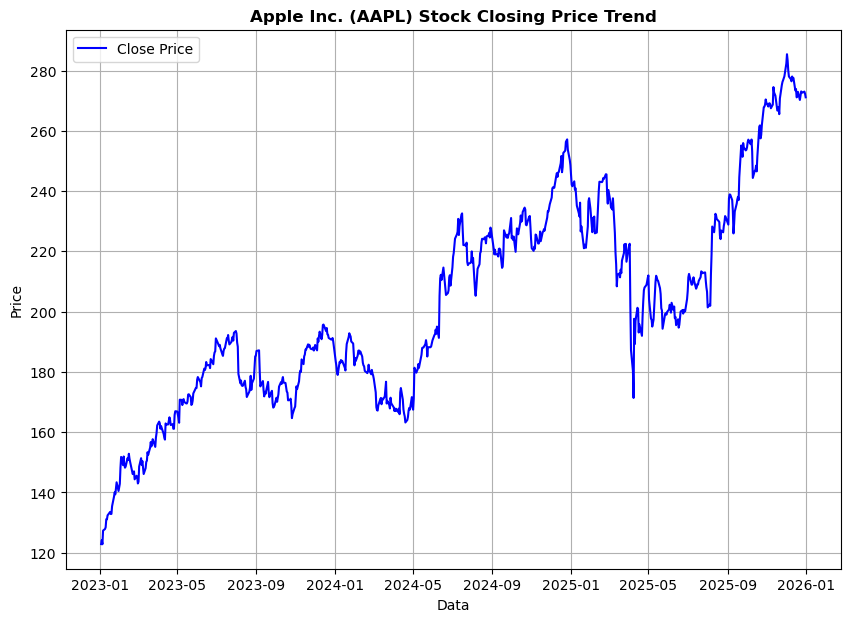

In [31]:
plt.figure(figsize=(10,7))
plt.plot(aapl_data.index,aapl_data["Close"],label="Close Price",color="blue")
plt.title("Apple Inc. (AAPL) Stock Closing Price Trend",fontweight="bold")
plt.xlabel("Data")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


### Moving Average Analysis

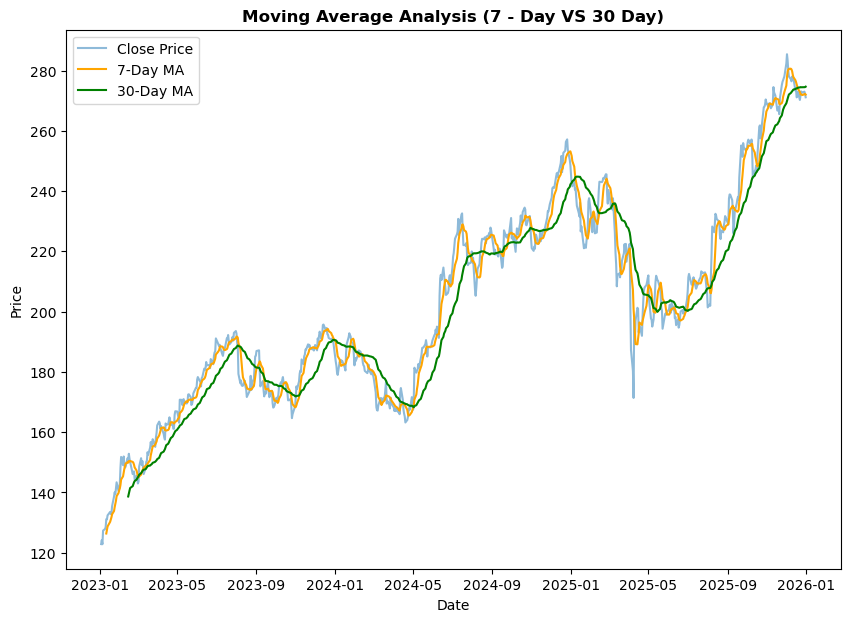

In [30]:
plt.figure(figsize=(10,7))
plt.plot(aapl_data.index , aapl_data["Close"],label="Close Price",color="gray",alpha=0.5)
plt.plot(aapl_data.index , aapl_data["MA_7"],label="7-Day MA",color="orange")
plt.plot(aapl_data.index, aapl_data["MA_30"],label="30-Day MA", color="green")
plt.title("Moving Average Analysis (7 - Day VS 30 Day)", fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

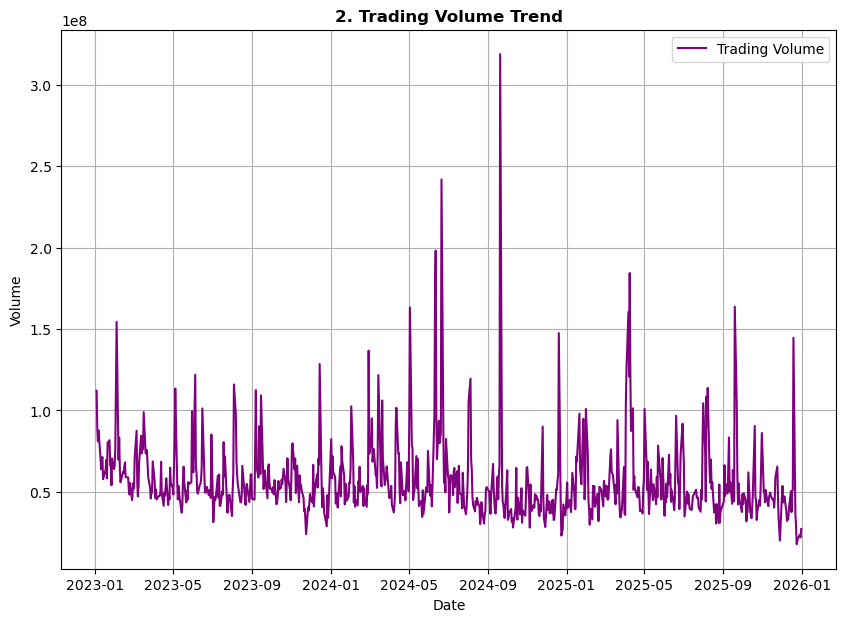

In [33]:
plt.figure(figsize=(10,7))
plt.plot(aapl_data.index, aapl_data["Volume"],color="purple",label="Trading Volume")
plt.title("2. Trading Volume Trend",fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.grid(True)
plt.show()

### Daily return percentage change analysis

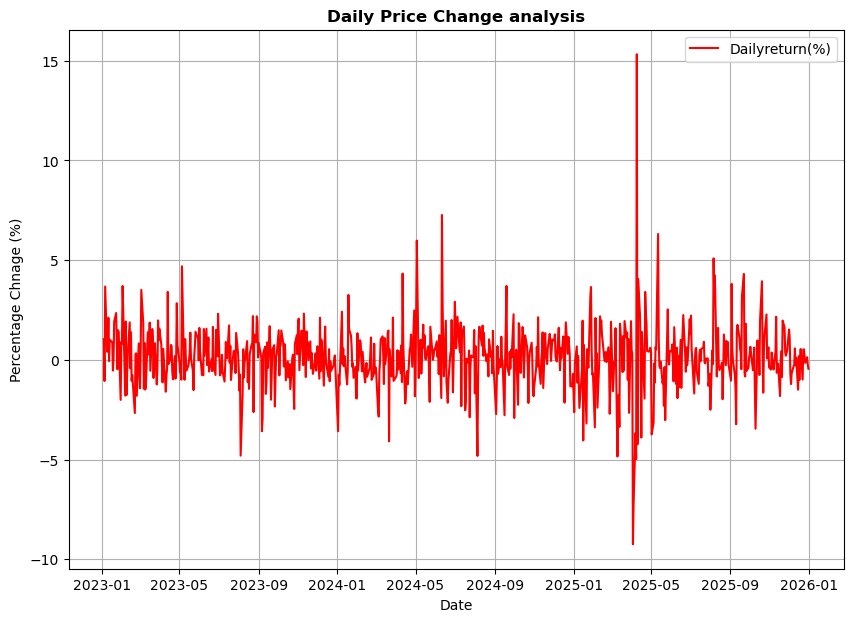

In [36]:
plt.figure(figsize=(10,7))
plt.plot(aapl_data.index,aapl_data["Pct_Price_change"],color="red",label="Dailyreturn(%)")
plt.title("Daily Price Change analysis",fontweight ="bold")
plt.xlabel("Date")
plt.ylabel("Percentage Chnage (%)")
plt.legend()
plt.grid(True)
plt.show()

### Daily Price Change

In [37]:
aapl_data["Daily Price change"]= aapl_data["Close"]-aapl_data["Open"]
print(aapl_data)

Price            Close        High         Low        Open     Volume  \
Date                                                                    
2023-01-03  122.876740  128.604497  121.992521  127.995375  112117500   
2023-01-04  124.144119  126.403789  122.886567  124.664824   89113600   
2023-01-05  122.827629  125.529405  122.572194  124.900628   80962700   
2023-01-06  127.346909  128.005157  122.699861  123.800222   87754700   
2023-01-09  127.867630  131.070471  127.612195  128.182026   70790800   
...                ...         ...         ...         ...        ...   
2025-12-24  273.066742  274.682340  271.461127  271.600731   17910600   
2025-12-26  272.657806  274.622460  272.119264  273.415753   21521800   
2025-12-29  273.016876  273.615223  271.610700  271.949773   23715200   
2025-12-30  272.338684  273.335969  271.540868  272.069428   22139600   
2025-12-31  271.122009  272.937076  271.012322  272.318764   27293600   

Price      Year_Month  Year  Month    DayName  Dai

### Percentage Price Change

In [40]:
aapl_data["Pct_Price_change"]=aapl_data["Close"].pct_change() * 100
print(aapl_data)

Price            Close        High         Low        Open     Volume  \
Date                                                                    
2023-01-03  122.876740  128.604497  121.992521  127.995375  112117500   
2023-01-04  124.144119  126.403789  122.886567  124.664824   89113600   
2023-01-05  122.827629  125.529405  122.572194  124.900628   80962700   
2023-01-06  127.346909  128.005157  122.699861  123.800222   87754700   
2023-01-09  127.867630  131.070471  127.612195  128.182026   70790800   
...                ...         ...         ...         ...        ...   
2025-12-24  273.066742  274.682340  271.461127  271.600731   17910600   
2025-12-26  272.657806  274.622460  272.119264  273.415753   21521800   
2025-12-29  273.016876  273.615223  271.610700  271.949773   23715200   
2025-12-30  272.338684  273.335969  271.540868  272.069428   22139600   
2025-12-31  271.122009  272.937076  271.012322  272.318764   27293600   

Price      Year_Month  Year  Month    DayName  Dai

### Monthly Returns (Month over month percentage returns)

In [42]:
aapl_data["Monthly_Return"]=aapl_data["Close"].resample("ME").ffill().pct_change()*100
print(aapl_data)

Price            Close        High         Low        Open     Volume  \
Date                                                                    
2023-01-03  122.876740  128.604497  121.992521  127.995375  112117500   
2023-01-04  124.144119  126.403789  122.886567  124.664824   89113600   
2023-01-05  122.827629  125.529405  122.572194  124.900628   80962700   
2023-01-06  127.346909  128.005157  122.699861  123.800222   87754700   
2023-01-09  127.867630  131.070471  127.612195  128.182026   70790800   
...                ...         ...         ...         ...        ...   
2025-12-24  273.066742  274.682340  271.461127  271.600731   17910600   
2025-12-26  272.657806  274.622460  272.119264  273.415753   21521800   
2025-12-29  273.016876  273.615223  271.610700  271.949773   23715200   
2025-12-30  272.338684  273.335969  271.540868  272.069428   22139600   
2025-12-31  271.122009  272.937076  271.012322  272.318764   27293600   

Price      Year_Month  Year  Month    DayName  Dai

### Volatility Measures

In [44]:
aapl_data["Volatility_30D"]=aapl_data["Pct_Price_change"].rolling(window=30).std
print(aapl_data)

Price            Close        High         Low        Open     Volume  \
Date                                                                    
2023-01-03  122.876740  128.604497  121.992521  127.995375  112117500   
2023-01-04  124.144119  126.403789  122.886567  124.664824   89113600   
2023-01-05  122.827629  125.529405  122.572194  124.900628   80962700   
2023-01-06  127.346909  128.005157  122.699861  123.800222   87754700   
2023-01-09  127.867630  131.070471  127.612195  128.182026   70790800   
...                ...         ...         ...         ...        ...   
2025-12-24  273.066742  274.682340  271.461127  271.600731   17910600   
2025-12-26  272.657806  274.622460  272.119264  273.415753   21521800   
2025-12-29  273.016876  273.615223  271.610700  271.949773   23715200   
2025-12-30  272.338684  273.335969  271.540868  272.069428   22139600   
2025-12-31  271.122009  272.937076  271.012322  272.318764   27293600   

Price      Year_Month  Year  Month    DayName  Dai

# Additional Features

### High Low spread (Intraday volatility) or Price Change %

In [45]:
aapl_data["High_low_Spread"]=aapl_data["High"]-aapl_data["Low"]
print(aapl_data)

Price            Close        High         Low        Open     Volume  \
Date                                                                    
2023-01-03  122.876740  128.604497  121.992521  127.995375  112117500   
2023-01-04  124.144119  126.403789  122.886567  124.664824   89113600   
2023-01-05  122.827629  125.529405  122.572194  124.900628   80962700   
2023-01-06  127.346909  128.005157  122.699861  123.800222   87754700   
2023-01-09  127.867630  131.070471  127.612195  128.182026   70790800   
...                ...         ...         ...         ...        ...   
2025-12-24  273.066742  274.682340  271.461127  271.600731   17910600   
2025-12-26  272.657806  274.622460  272.119264  273.415753   21521800   
2025-12-29  273.016876  273.615223  271.610700  271.949773   23715200   
2025-12-30  272.338684  273.335969  271.540868  272.069428   22139600   
2025-12-31  271.122009  272.937076  271.012322  272.318764   27293600   

Price      Year_Month  Year  Month    DayName  Dai

In [46]:
aapl_data["Price_range_pct"]=(aapl_data["High"]-aapl_data["Low"])/aapl_data["Low"]*100

In [47]:
print(aapl_data)

Price            Close        High         Low        Open     Volume  \
Date                                                                    
2023-01-03  122.876740  128.604497  121.992521  127.995375  112117500   
2023-01-04  124.144119  126.403789  122.886567  124.664824   89113600   
2023-01-05  122.827629  125.529405  122.572194  124.900628   80962700   
2023-01-06  127.346909  128.005157  122.699861  123.800222   87754700   
2023-01-09  127.867630  131.070471  127.612195  128.182026   70790800   
...                ...         ...         ...         ...        ...   
2025-12-24  273.066742  274.682340  271.461127  271.600731   17910600   
2025-12-26  272.657806  274.622460  272.119264  273.415753   21521800   
2025-12-29  273.016876  273.615223  271.610700  271.949773   23715200   
2025-12-30  272.338684  273.335969  271.540868  272.069428   22139600   
2025-12-31  271.122009  272.937076  271.012322  272.318764   27293600   

Price      Year_Month  Year  Month    DayName  Dai

In [50]:
print(aapl_data[["Close","Low","High","Pct_Price_change","MA_7","Volatility_30D","High_low_Spread"]])

Price            Close         Low        High  Pct_Price_change        MA_7  \
Date                                                                           
2023-01-03  122.876740  121.992521  128.604497               NaN         NaN   
2023-01-04  124.144119  122.886567  126.403789          1.031424         NaN   
2023-01-05  122.827629  122.572194  125.529405         -1.060453         NaN   
2023-01-06  127.346909  122.699861  128.005157          3.679367         NaN   
2023-01-09  127.867630  127.612195  131.070471          0.408900         NaN   
...                ...         ...         ...               ...         ...   
2025-12-24  273.066742  271.461127  274.682340          0.532388  272.038099   
2025-12-26  272.657806  272.119264  274.622460         -0.149757  271.865710   
2025-12-29  273.016876  271.610700  273.615223          0.131692  272.139256   
2025-12-30  272.338684  271.540868  273.335969         -0.248407  272.266052   
2025-12-31  271.122009  271.012322  272.